# [시장분석] 서울 아파트 연평균 상승률은 얼마일까? - 10년·20년·30년 비교

기준연월을 확인하고 코드 셀을 실행하세요. KB 서울 아파트 월간 매매가격지수의 최근 30년 추이 PNG와 월별 CSV를 생성합니다.

기간,시작,종료,누적 상승률,연평균 상승률
최근 10년,2016.7,2026.7,86.2%,6.4%
최근 20년,2006.7,2026.7,129.6%,4.2%
최근 30년,1996.7,2026.7,408.2%,5.6%


KB 자료 업데이트일: **2026년 08월 10일**

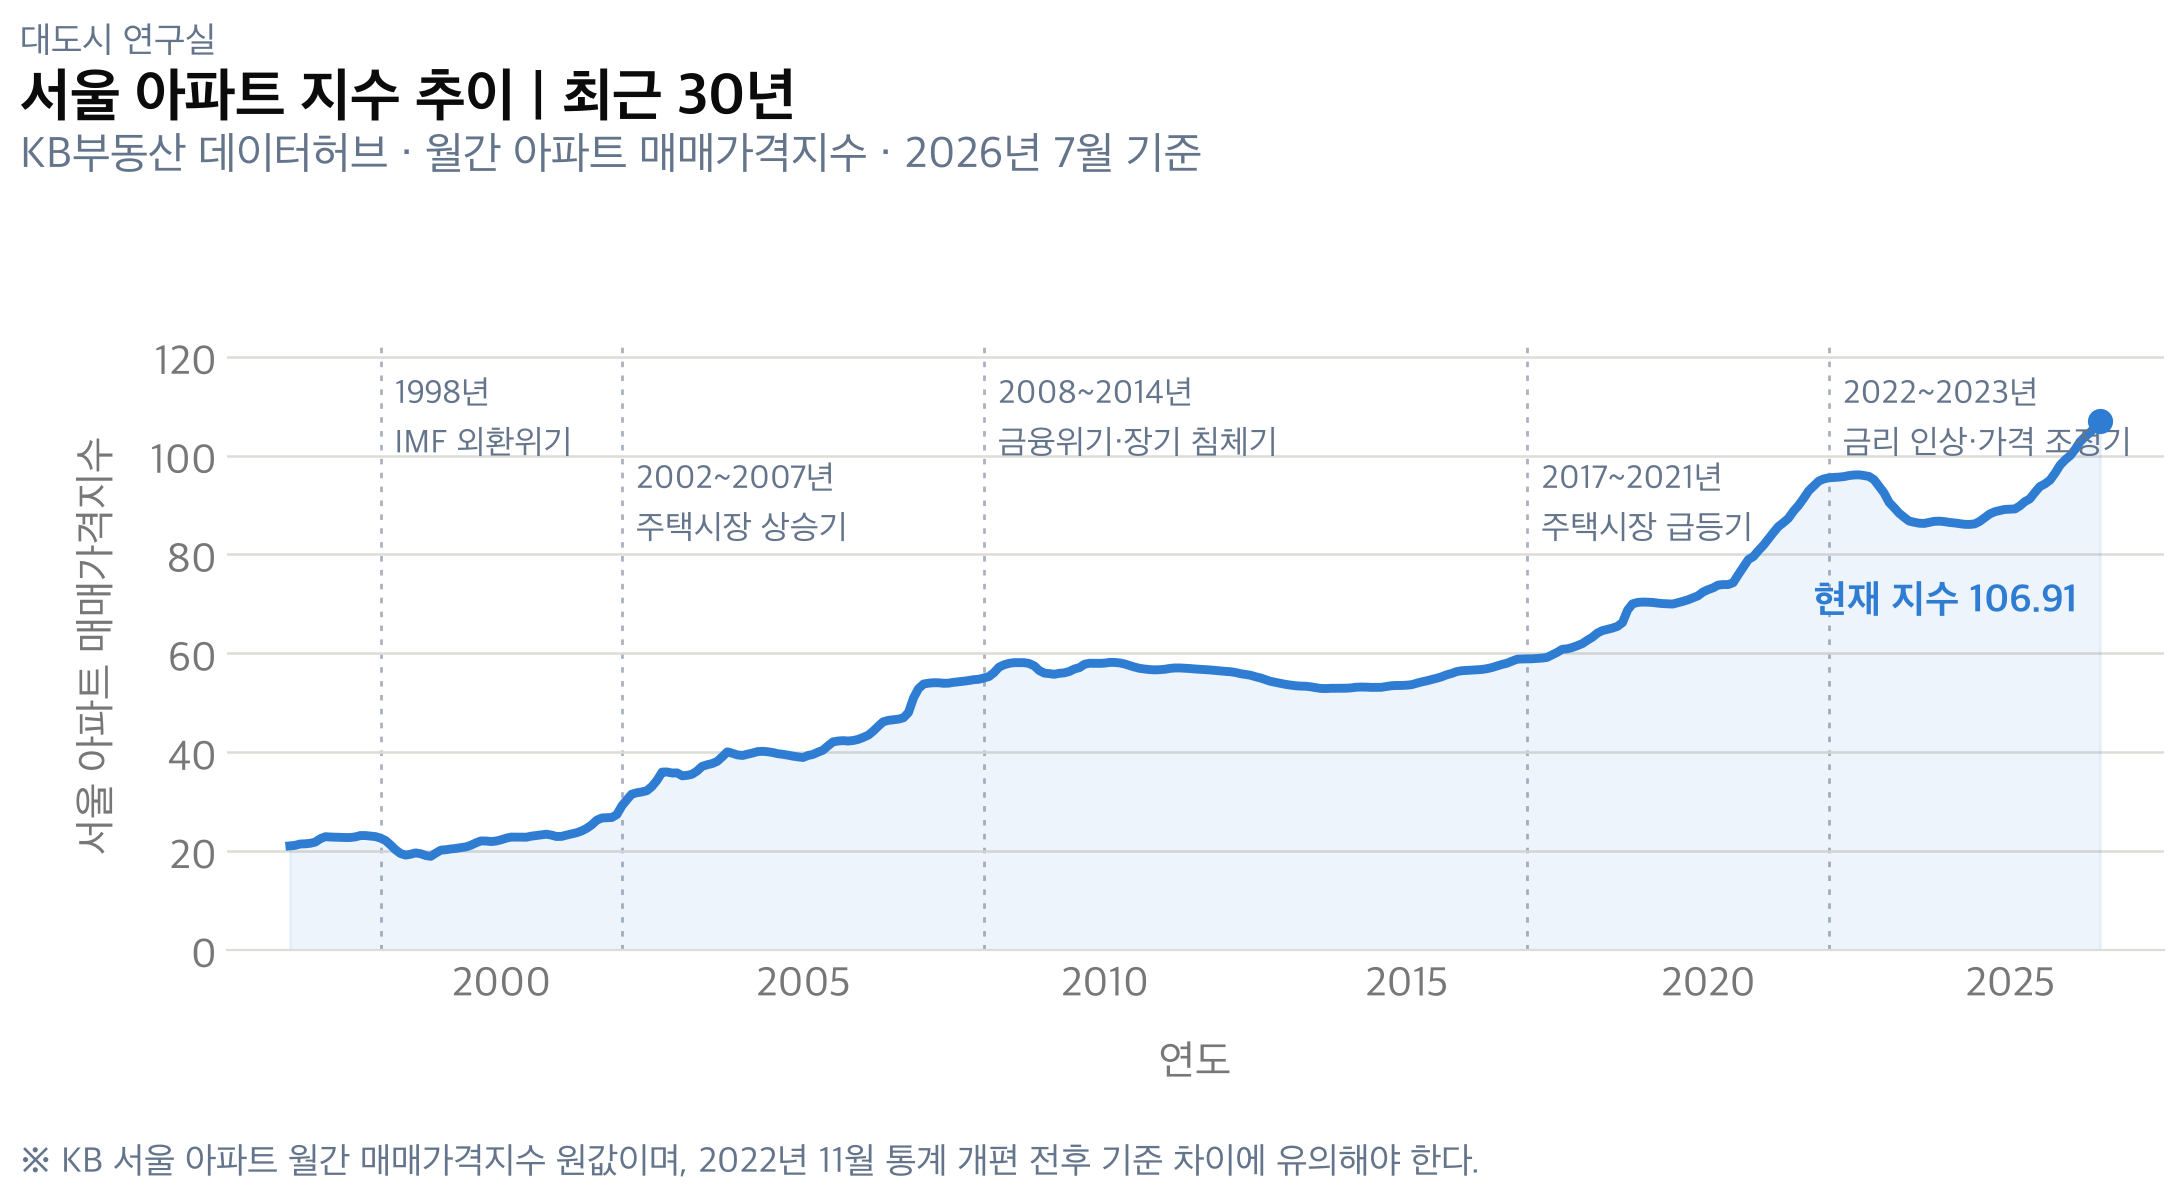

[KB 매매가격지수 원자료](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=monthAptMonthSalePriceInx)

/Users/1111429/src/daedosee-lab/an_apt_seoul_growth/output/seoul_apartment_price_growth_summary.csv

/Users/1111429/src/daedosee-lab/an_apt_seoul_growth/output/seoul_apartment_price_index_30y.csv

/Users/1111429/src/daedosee-lab/an_apt_seoul_growth/output/seoul_apartment_price_index_30y.png

In [1]:
# @title 기준연월을 입력하고 실행하세요
기준연도 = 2026  # @param {type:"integer", min:2016, step:1}
기준월 = 7  # @param {type:"integer", min:1, max:12, step:1}

"""KB 서울 아파트 월간 매매가격지수의 최근 30년 추이를 표시한다.

KB부동산 데이터허브 주택가격동향조사의 서울 아파트 월간
매매가격지수 원시계열을 사용한다. 기준연월부터 정확히 30년 전의
같은 달까지 표시하며 물가상승률은 반영하지 않는다.
"""

import json
import os
from pathlib import Path
from urllib.parse import urlencode
from urllib.request import Request, urlopen

import matplotlib
matplotlib.use("Agg")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import font_manager
import pandas as pd
from IPython.display import FileLink, HTML, Image, Markdown, display

IS_COLAB = bool(os.environ.get("COLAB_RELEASE_TAG")) or Path("/content").exists()
OUTPUT_DIR = Path("/content/output") if IS_COLAB else Path("output")
END_YEAR = int(기준연도)
END_MONTH = int(기준월)
PERIOD_YEARS = 30
SUMMARY_PERIOD_YEARS = (10, 20, 30)
END_PERIOD = pd.Period(year=END_YEAR, month=END_MONTH, freq="M")
START_PERIOD = END_PERIOD - PERIOD_YEARS * 12
SEOUL_REGION_CODE = "1100000000"
KB_API_URL = (
    "https://data-api.kbland.kr/bfmstat/weekMnthlyHuseTrnd/"
    "priceIndexOnlyMonthAptExcel"
)
KB_SOURCE_URL = (
    "https://data.kbland.kr/kbstats/wmh?"
    "tIdx=HT01&tsIdx=monthAptMonthSalePriceInx"
)
BACKGROUND_COLOR = "#FFFFFF"
TEXT_COLOR = "#0B0B0B"
SECONDARY_TEXT_COLOR = "#64748B"
PRICE_COLOR = "#2F7DD3"
GRID_COLOR = "#DEDCD6"
TICK_COLOR = "#777777"
BRAND_SIZE = 13
TITLE_SIZE = 21
SUBTITLE_SIZE = 16
AXIS_TITLE_SIZE = 15
TICK_SIZE = 15
DATA_LABEL_SIZE = 14
FOOTNOTE_SIZE = 13
CONTENT_LEFT = 0.025
FONT_CANDIDATES = (
    "Pretendard",
    "Apple SD Gothic Neo",
    "Noto Sans CJK KR",
    "Malgun Gothic",
)


def validate_parameters() -> None:
    """기준연월과 최근 30년 시작 시점을 검증한다."""
    if not 1 <= END_MONTH <= 12:
        raise ValueError("기준월은 1~12월이어야 합니다.")
    if START_PERIOD < pd.Period("1986-01", freq="M"):
        raise ValueError("KB 지수 시작 전 기간은 조회할 수 없습니다.")


def download_seoul_apartment_index() -> tuple[pd.Series, str]:
    """KB에서 서울 아파트 월간 매매가격지수 전체 시계열을 받는다."""
    params = {
        "매매전세코드": "01",
        "월간주간구분코드": "01",
        "매물종별구분": "01",
        "지역코드": "",
        "type": "false",
    }
    request = Request(
        f"{KB_API_URL}?{urlencode(params)}",
        headers={
            "osType": "HUB",
            "User-Agent": "Mozilla/5.0",
            "Referer": "https://data.kbland.kr/",
        },
    )
    with urlopen(request, timeout=60) as response:
        payload = json.load(response)
    header = payload.get("dataHeader", {})
    if header.get("resultCode") != "10000":
        raise RuntimeError(
            "KB 가격지수를 받지 못했습니다: "
            + header.get("message", "알 수 없는 오류")
        )
    body = payload["dataBody"]["data"]
    seoul = next(
        (
            row for row in body["데이터리스트"]
            if row["지역코드"] == SEOUL_REGION_CODE
        ),
        None,
    )
    if seoul is None:
        raise RuntimeError("KB 가격지수에서 서울 자료를 찾지 못했습니다.")
    dates = pd.PeriodIndex(
        [item["기준날짜"] for item in seoul["dataList"]], freq="M"
    )
    values = pd.to_numeric(
        [item["데이터"] for item in seoul["dataList"]], errors="coerce"
    )
    series = pd.Series(values, index=dates, name="서울 아파트 매매가격지수").dropna()
    return series, str(body["업데이트일자"])


def select_analysis_period(price_index: pd.Series) -> pd.Series:
    """기준연월까지 최근 30년의 월별 지수를 선택한다."""
    missing = [
        period for period in (START_PERIOD, END_PERIOD)
        if period not in price_index.index
    ]
    if missing:
        latest = price_index.index.max()
        raise RuntimeError(
            f"필요한 지수가 없습니다: {', '.join(map(str, missing))}. "
            f"최신 자료는 {latest}입니다."
        )
    selected = price_index.loc[START_PERIOD:END_PERIOD].copy()
    expected_months = PERIOD_YEARS * 12 + 1
    if len(selected) != expected_months:
        raise RuntimeError(
            f"최근 {PERIOD_YEARS}년 월별 지수가 "
            f"{expected_months}개가 아닌 {len(selected)}개입니다."
        )
    return selected


def calculate_growth_summary(price_index: pd.Series) -> pd.DataFrame:
    """최근 10·20·30년의 누적 상승률과 CAGR을 계산한다."""
    if END_PERIOD not in price_index.index:
        raise RuntimeError(f"{END_PERIOD} 서울 아파트 지수가 없습니다.")
    ending_index = float(price_index.loc[END_PERIOD])
    rows = []
    for years in SUMMARY_PERIOD_YEARS:
        start_period = END_PERIOD - years * 12
        if start_period not in price_index.index:
            raise RuntimeError(f"{start_period} 서울 아파트 지수가 없습니다.")
        starting_index = float(price_index.loc[start_period])
        growth_multiple = ending_index / starting_index
        rows.append({
            "기간": f"최근 {years}년",
            "시작": str(start_period),
            "종료": str(END_PERIOD),
            "시작지수": starting_index,
            "종료지수": ending_index,
            "누적_상승률": growth_multiple - 1,
            "연평균_상승률": growth_multiple ** (1 / years) - 1,
        })
    return pd.DataFrame(rows)


def format_period(period_text: str) -> str:
    """YYYY-MM 형식을 YYYY.M 형식으로 바꾼다."""
    year, month = period_text.split("-")
    return f"{year}.{int(month)}"


def build_growth_table_html(summary: pd.DataFrame) -> str:
    """최근 10·20·30년 상승률을 스타일 가이드의 HTML 표로 만든다."""
    table = pd.DataFrame({
        "기간": summary["기간"],
        "시작": summary["시작"].map(format_period),
        "종료": summary["종료"].map(format_period),
        "누적 상승률": summary["누적_상승률"].map("{:.1%}".format),
        "연평균 상승률": summary["연평균_상승률"].map("{:.1%}".format),
    })
    table_html = table.to_html(
        index=False, border=0, classes="growth-result-table", escape=False
    )
    return f"""
<style>
.growth-result-section {{
  max-width:700px; margin:12px 0 28px;
  font-family:Pretendard,-apple-system,BlinkMacSystemFont,
  'Segoe UI',sans-serif;
}}
.growth-result-header {{ margin:0 0 14px; }}
.growth-result-brand {{
  margin:0 0 5px; color:#64748b; font-size:13px; font-weight:400;
}}
.growth-result-title {{
  margin:0 0 5px; color:#0b0b0b; font-size:21px;
  line-height:1.3; font-weight:700;
}}
.growth-result-subtitle {{
  margin:0; color:#64748b; font-size:16px; line-height:1.4;
  font-weight:400;
}}
.growth-result-wrap {{
  overflow-x:auto; border:1px solid #f0f2f5; border-radius:12px;
}}
.growth-result-table {{
  width:100%; border-collapse:separate; border-spacing:0;
  font-size:13px; font-variant-numeric:tabular-nums; color:#1e293b;
}}
.growth-result-table thead th {{
  padding:8px 12px; background:#2b4a75;
  border-bottom:2px solid #7fb3d5; color:white; font-weight:700;
  text-align:center; white-space:nowrap;
}}
.growth-result-table tbody td {{
  padding:7px 12px; border-bottom:1px solid #f0f2f5;
  background:white; text-align:center; white-space:nowrap;
}}
.growth-result-table tbody tr:nth-child(even) td {{ background:#fafbfc; }}
.growth-result-table tbody tr:hover td {{ background:#eff6ff; }}
.growth-result-table tbody tr:last-child td {{ border-bottom:0; }}
.growth-result-table tbody td:first-child {{ font-weight:600; }}
.growth-result-table tbody td:nth-child(n+4) {{ text-align:right; }}
.growth-result-notes {{
  margin:10px 0 0; color:#64748b; font-size:13px; line-height:1.5;
}}
</style>
<section class="growth-result-section">
  <div class="growth-result-header">
    <p class="growth-result-brand">대도시 연구실</p>
    <h2 class="growth-result-title">서울 아파트 지수 기준 상승률 | 최근 10·20·30년</h2>
    <p class="growth-result-subtitle">KB 월간 아파트 매매가격지수 · {END_YEAR}년 {END_MONTH}월 기준 · 명목</p>
  </div>
  <div class="growth-result-wrap">{table_html}</div>
  <p class="growth-result-notes">
    ※ 누적 상승률=(종료지수÷시작지수)-1 · 연평균 상승률=CAGR<br>
    ※ 물가상승률을 차감하지 않은 명목 기준 · 2022년 11월 통계개편 유의
  </p>
</section>
"""


def configure_korean_font() -> None:
    """사용 가능한 한글 글꼴을 Matplotlib에 설정한다."""
    installed = {font.name for font in font_manager.fontManager.ttflist}
    font_name = next(
        (name for name in FONT_CANDIDATES if name in installed), None
    )
    if font_name:
        plt.rcParams["font.family"] = font_name
    plt.rcParams["axes.unicode_minus"] = False


def save_price_index_chart(price_index: pd.Series, output_path: Path) -> None:
    """서울 아파트 매매가격지수의 최근 30년 추이 그래프를 저장한다."""
    configure_korean_font()
    dates = price_index.index.to_timestamp()
    fig, ax = plt.subplots(figsize=(11.5, 6.2))
    fig.patch.set_facecolor(BACKGROUND_COLOR)
    ax.set_facecolor(BACKGROUND_COLOR)
    ax.plot(dates, price_index, color=PRICE_COLOR, linewidth=3.2, zorder=3)
    ax.fill_between(
        dates, price_index.to_numpy(), color=PRICE_COLOR, alpha=0.08, zorder=2
    )

    market_phases = (
        ("1998-01-01", "1998년\nIMF 외환위기", 0.96),
        ("2002-01-01", "2002~2007년\n주택시장 상승기", 0.82),
        ("2008-01-01", "2008~2014년\n금융위기·장기 침체기", 0.96),
        ("2017-01-01", "2017~2021년\n주택시장 급등기", 0.82),
        ("2022-01-01", "2022~2023년\n금리 인상·가격 조정기", 0.96),
    )
    for phase_date, phase_label, label_y in market_phases:
        phase_timestamp = pd.Timestamp(phase_date)
        ax.axvline(
            phase_timestamp, color=SECONDARY_TEXT_COLOR, linewidth=1.0,
            linestyle=(0, (2, 3)), alpha=0.55, zorder=1,
        )
        ax.annotate(
            phase_label, xy=(phase_timestamp, label_y),
            xycoords=("data", "axes fraction"), xytext=(5, 0),
            textcoords="offset points", ha="left", va="top",
            fontsize=FOOTNOTE_SIZE - 1, linespacing=1.25,
            color=SECONDARY_TEXT_COLOR,
        )

    final_date = dates[-1]
    final_index = float(price_index.iloc[-1])
    ax.scatter(final_date, final_index, color=PRICE_COLOR, s=65, zorder=4)
    ax.annotate(
        f"현재 지수 {final_index:.2f}",
        xy=(final_date, final_index * 0.66), xytext=(-8, 0),
        textcoords="offset points", ha="right", va="center",
        fontsize=DATA_LABEL_SIZE, fontweight="bold", color=PRICE_COLOR,
    )
    fig.text(
        CONTENT_LEFT, 0.975, "대도시 연구실", ha="left", va="top",
        fontsize=BRAND_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    fig.suptitle(
        "서울 아파트 지수 추이 | 최근 30년",
        x=CONTENT_LEFT, y=0.94, ha="left", fontsize=TITLE_SIZE,
        fontweight="bold", color=TEXT_COLOR,
    )
    fig.text(
        CONTENT_LEFT, 0.855,
        "KB부동산 데이터허브 · 월간 아파트 매매가격지수 · "
        f"{END_YEAR}년 {END_MONTH}월 기준",
        ha="left", fontsize=SUBTITLE_SIZE, color=SECONDARY_TEXT_COLOR,
    )
    ax.set_xlabel(
        "연도", fontsize=AXIS_TITLE_SIZE, color=TICK_COLOR, labelpad=10
    )
    ax.set_ylabel(
        "서울 아파트 매매가격지수",
        fontsize=AXIS_TITLE_SIZE, color=TICK_COLOR, labelpad=10,
    )
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:g}"))
    ax.tick_params(
        axis="both", colors=TICK_COLOR, labelsize=TICK_SIZE, length=0
    )
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.9, zorder=0)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.set_ylim(0, float(price_index.max()) * 1.15)
    ax.margins(x=0.035)
    fig.text(
        CONTENT_LEFT, 0.045,
        "※ KB 서울 아파트 월간 매매가격지수 원값이며, "
        "2022년 11월 통계 개편 전후 기준 차이에 유의해야 한다.",
        fontsize=FOOTNOTE_SIZE, color=SECONDARY_TEXT_COLOR, ha="left",
    )
    fig.tight_layout(rect=(0.035, 0.09, 0.97, 0.82))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        output_path, dpi=200, bbox_inches="tight",
        facecolor=BACKGROUND_COLOR,
    )
    plt.close(fig)


def save_results(
    price_index: pd.Series, summary: pd.DataFrame
) -> tuple[Path, Path, Path]:
    """상승률 요약, 최근 30년 월별 지수와 추이 PNG를 저장한다."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    summary_path = OUTPUT_DIR / "seoul_apartment_price_growth_summary.csv"
    csv_path = OUTPUT_DIR / "seoul_apartment_price_index_30y.csv"
    chart_path = OUTPUT_DIR / "seoul_apartment_price_index_30y.png"
    output_table = price_index.rename("매매가격지수").rename_axis("기준월").reset_index()
    output_table["기준월"] = output_table["기준월"].astype(str)
    summary.to_csv(summary_path, index=False, encoding="utf-8-sig")
    output_table.to_csv(csv_path, index=False, encoding="utf-8-sig")
    save_price_index_chart(price_index, chart_path)
    return summary_path, csv_path, chart_path


def display_results(
    summary: pd.DataFrame, update_date: str,
    summary_path: Path, csv_path: Path, chart_path: Path,
) -> None:
    """자료 업데이트일, 그래프와 저장 파일 링크를 표시한다."""
    update_label = pd.to_datetime(update_date).strftime("%Y년 %m월 %d일")
    display(HTML(build_growth_table_html(summary)))
    display(Markdown(f"KB 자료 업데이트일: **{update_label}**"))
    display(Image(filename=str(chart_path)))
    display(Markdown(f"[KB 매매가격지수 원자료]({KB_SOURCE_URL})"))
    if not IS_COLAB:
        display(
            FileLink(str(summary_path)), FileLink(str(csv_path)),
            FileLink(str(chart_path)),
        )


def main() -> None:
    """입력 검증부터 데이터 수집, 저장과 출력까지 실행한다."""
    validate_parameters()
    full_index, update_date = download_seoul_apartment_index()
    price_index = select_analysis_period(full_index)
    summary = calculate_growth_summary(full_index)
    summary_path, csv_path, chart_path = save_results(price_index, summary)
    display_results(
        summary, update_date, summary_path, csv_path, chart_path
    )


main()
